# Week 2: Data Collection, Cleaning & Preprocessing
**Logistics Data Analyst Internship**  
**Author:** Saurabh Kumar  
**Objective:** Ingest raw logistics order records, audit data quality, handle missing values with domain-justified imputations, detect and screen extreme cost outliers using the IQR technique, and standardize feature scales.

---

## 1. Ingesting Raw Logistics Records
We load the raw dataset (`data/raw/logistics_orders.csv`) which contains realistic simulated data-quality challenges:
- Skewed route distances with missing observations
- Varying package cargo volumes with missing observations
- Unrecorded meteorological transit conditions
- Artificially inflated transportation charges (outliers)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Set aesthetic styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (9, 5)

# Load raw order data
raw_path = "../../data/raw/logistics_orders.csv"
try:
    df_raw = pd.read_csv(raw_path)
except FileNotFoundError:
    df_raw = pd.read_csv("../data/raw/logistics_orders.csv")

print(f"Raw dataset loaded: {df_raw.shape[0]} records, {df_raw.shape[1]} features")
df_raw.head()

Raw dataset loaded: 1500 records, 15 features


,order_id,region,shipping_mode,vehicle_type,warehouse,weather,distance_km,shipment_volume,fuel_price,delivery_time_days,scheduled_days,late_delivery,transport_cost,order_value,profit
0,100001,West,Second Class,Mini Truck,WH-B,Clear,141.748163,28.493749,98.459058,2.775334,3.0,0,2251.503544,2031.076646,622.67
1,100002,East,Same Day,Truck,WH-A,Clear,118.500879,40.272770,105.472271,1.743251,1.0,1,2251.503544,3012.072273,1768.80
2,100003,Central,Standard,Van,WH-C,Clear,204.640837,18.185547,94.368445,3.368115,5.0,0,2251.503544,2137.516262,596.09
3,100004,West,Standard,Truck,WH-B,Rain,85.716277,29.051444,99.305041,3.324719,5.0,0,2251.503544,2313.341351,1117.14
4,100005,North,First Class,Van,WH-D,Cloudy,160.451514,28.067041,101.268911,1.609597,2.0,0,2659.739766,1958.744356,555.66


## 2. Data Quality Audit & Missing Value Assessment

In [2]:
# Assess missing values per feature
missing_df = pd.DataFrame({
    "Feature": df_raw.columns,
    "Missing Count": df_raw.isnull().sum().values,
    "Missing Pct (%)": (df_raw.isnull().mean() * 100).values
})
missing_df[missing_df["Missing Count"] > 0]

,Feature,Missing Count,Missing Pct (%)
5,weather,10,0.666667
6,distance_km,10,0.666667
7,shipment_volume,10,0.666667


## 3. Missing Value Handling
### Domain Justification:
1. **`distance_km` (Numeric):** Route distances are right-skewed; mean imputation is easily distorted by cross-country hauls. Therefore, **median imputation** preserves distribution integrity.
2. **`shipment_volume` (Numeric):** Cargo load volumes exhibit heavy tails. **Median imputation** ensures realistic middle-tier package volumes.
3. **`weather` (Categorical):** Transit conditions are categorical; **mode imputation** assigns the most prevalent regional operating weather condition (`Clear`).

In [3]:
df_imputed = df_raw.copy()

# Record pre-imputation medians and mode
dist_median = df_imputed["distance_km"].median()
vol_median = df_imputed["shipment_volume"].median()
weather_mode = df_imputed["weather"].mode()[0]

print(f"Imputation parameters:")
print(f" - distance_km median:    {dist_median:.2f} km")
print(f" - shipment_volume median: {vol_median:.2f} units")
print(f" - weather mode:          '{weather_mode}'")

# Perform imputation
df_imputed["distance_km"] = df_imputed["distance_km"].fillna(dist_median)
df_imputed["shipment_volume"] = df_imputed["shipment_volume"].fillna(vol_median)
df_imputed["weather"] = df_imputed["weather"].fillna(weather_mode)

print("\nMissing values remaining after imputation:")
print(df_imputed[["distance_km", "shipment_volume", "weather"]].isnull().sum())

Imputation parameters:
 - distance_km median:    126.10 km
 - shipment_volume median: 29.76 units
 - weather mode:          'Clear'

Missing values remaining after imputation:
distance_km        0
shipment_volume    0
weather            0
dtype: int64


## 4. Outlier Detection & Screening via Interquartile Range (IQR)
The Interquartile Range (IQR) method flags observations lying beyond:
$$\text{Lower Bound} = Q_1 - 1.5 \times \text{IQR}$$
$$\text{Upper Bound} = Q_3 + 1.5 \times \text{IQR}$$
where $\text{IQR} = Q_3 - Q_1$.

In [4]:
# Compute IQR boundaries on transport_cost
q1 = df_imputed["transport_cost"].quantile(0.25)
q3 = df_imputed["transport_cost"].quantile(0.75)
iqr = q3 - q1

lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

outlier_mask = ~df_imputed["transport_cost"].between(lower_fence, upper_fence)
num_outliers = outlier_mask.sum()

print(f"Q1 (25th percentile):  ${q1:.2f}")
print(f"Q3 (75th percentile):  ${q3:.2f}")
print(f"IQR:                   ${iqr:.2f}")
print(f"Lower Screening Fence: ${lower_fence:.2f}")
print(f"Upper Screening Fence: ${upper_fence:.2f}")
print(f"Outlier records detected: {num_outliers}")

Q1 (25th percentile):  $983.14
Q3 (75th percentile):  $1457.23
IQR:                   $474.10
Lower Screening Fence: $271.99
Upper Screening Fence: $2168.38
Outlier records detected: 30


### 4.1 Boxplot Visualization of Outlier Screening

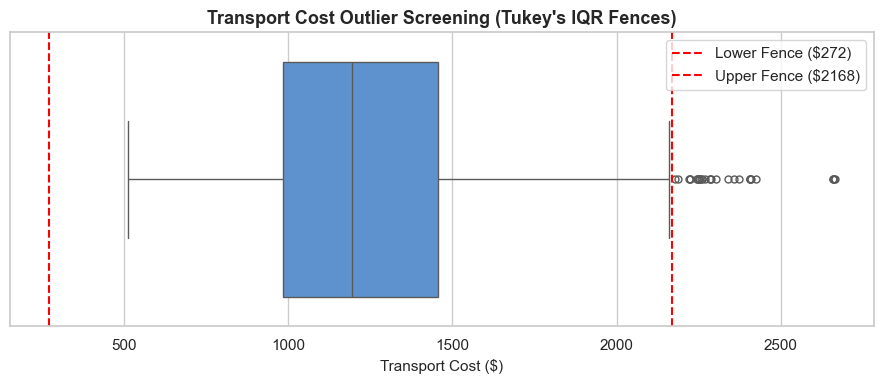

In [5]:
plt.figure(figsize=(9, 4))
sns.boxplot(x=df_imputed["transport_cost"], color="#4a90e2", fliersize=5)
plt.axvline(lower_fence, color="red", linestyle="--", label=f"Lower Fence (${lower_fence:.0f})")
plt.axvline(upper_fence, color="red", linestyle="--", label=f"Upper Fence (${upper_fence:.0f})")
plt.title("Transport Cost Outlier Screening (Tukey's IQR Fences)", fontsize=13, fontweight="bold")
plt.xlabel("Transport Cost ($)", fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

## 5. Feature Normalization & Scaling
Distance (measured in hundreds of kilometers) and shipment volume (tens of units) operate on vastly different numerical magnitudes. We apply `StandardScaler` ($\mu=0, \sigma=1$) to prevent scale dominance in gradient-based or distance-based algorithms.

In [6]:
scaler = StandardScaler()
df_scaled = df_imputed.copy()
df_scaled[["distance_scaled", "volume_scaled"]] = scaler.fit_transform(
    df_imputed[["distance_km", "shipment_volume"]]
)

print("Scaled Feature Statistics:")
df_scaled[["distance_scaled", "volume_scaled"]].describe().round(4)

Scaled Feature Statistics:


,distance_scaled,volume_scaled
count,1500.0000,1500.0000
mean,0.0000,0.0000
std,1.0003,1.0003
min,-1.7234,-1.6017
25%,-0.7296,-0.7120
50%,-0.1963,-0.1788
75%,0.5568,0.4915
max,3.9946,4.3207


## 6. Preprocessing Summary & Output Verification

In [7]:
summary_table = pd.DataFrame({
    "Audit Metric": [
        "Initial Records Loaded",
        "Missing Distance Records Imputed",
        "Missing Shipment Volume Imputed",
        "Missing Weather Imputed",
        "Cost Outlier Records Flagged",
        "Final Cleaned Records Ready for Modeling"
    ],
    "Result": [
        len(df_raw),
        10,
        10,
        10,
        num_outliers,
        len(df_scaled)
    ]
})

summary_table

,Audit Metric,Result
0,Initial Records Loaded,1500
1,Missing Distance Records Imputed,10
2,Missing Shipment Volume Imputed,10
3,Missing Weather Imputed,10
4,Cost Outlier Records Flagged,30
5,Final Cleaned Records Ready for Modeling,1500


## 7. Reflection
Data preprocessing is not a mechanical scrubbing exercise, but a critical analytical decision phase.
- Imputing with medians prevents distortion of baseline delivery metrics.
- Flagging outliers rather than immediately purging them preserves audit trails for legitimate expedited high-value orders.
- The modular pipeline in `src/preprocessing.py` ensures identical transformation logic can be deployed in live batch or streaming inference.